# Results Analysis

Compare completed experiment outputs under `results/<exp_name>/`. This notebook reads saved metrics only; it does not train models.

In [1]:
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)

from src.data.load import LABELS
from src.utils.io import ensure_dir

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURE_DIR = ensure_dir(RESULTS_DIR / "figures/experiments")
EXPERIMENT_ORDER = [
    "exp_A_cnn_scratch",
    "exp_B_transfer",
    "exp_C_class_weight",
    "exp_D_focal_loss",
    "exp_E_augmentation",
    "exp_F_svm",
]

## Comparison Table

In [2]:
metric_paths = sorted(RESULTS_DIR.glob("exp_*/metrics.json"))
metrics_by_exp = {}
for path in metric_paths:
    with path.open("r", encoding="utf-8") as file:
        metrics = json.load(file)
    if "per_class" not in metrics:
        continue
    metrics_by_exp[path.parent.name] = metrics

rows = []
for exp_name in EXPERIMENT_ORDER:
    if exp_name not in metrics_by_exp:
        continue
    metrics = metrics_by_exp[exp_name]
    row = {
        "experiment": exp_name,
        "accuracy": metrics.get("accuracy"),
        "macro_f1": metrics.get("macro_f1"),
        "kappa": metrics.get("cohen_kappa"),
    }
    for class_name in LABELS:
        row[f"f1_{class_name}"] = metrics["per_class"][class_name]["f1"]
    rows.append(row)

comparison_df = pd.DataFrame(rows)
if comparison_df.empty:
    raise FileNotFoundError("No metrics.json files with per_class metrics found.")

comparison_csv = RESULTS_DIR / "comparison_table.csv"
comparison_md = RESULTS_DIR / "comparison_table.md"
comparison_df.to_csv(comparison_csv, index=False)

def dataframe_to_markdown(df):
    rounded = df.copy()
    numeric_cols = rounded.select_dtypes(include="number").columns
    rounded[numeric_cols] = rounded[numeric_cols].round(4)
    header = "| " + " | ".join(rounded.columns) + " |"
    separator = "| " + " | ".join(["---"] * len(rounded.columns)) + " |"
    body = ["| " + " | ".join(map(str, row)) + " |" for row in rounded.to_numpy()]
    return "\n".join([header, separator, *body]) + "\n"

comparison_md.write_text(dataframe_to_markdown(comparison_df), encoding="utf-8")
display(comparison_df)

,experiment,accuracy,macro_f1,kappa,f1_Center,f1_Donut,f1_Edge-Loc,f1_Edge-Ring,f1_Loc,f1_Near-full,f1_Random,f1_Scratch,f1_none
0,exp_A_cnn_scratch,0.972324,0.850198,0.894976,0.928857,0.735484,0.803538,0.972376,0.731707,0.954545,0.852590,0.684039,0.988642
1,exp_B_transfer,0.972362,0.846824,0.895108,0.935308,0.789809,0.815860,0.973973,0.732394,1.000000,0.885496,0.500000,0.988575
2,exp_C_class_weight,0.940870,0.791920,0.801325,0.873481,0.807453,0.671211,0.964273,0.541004,0.771930,0.836364,0.689873,0.971692
3,exp_D_focal_loss,0.972555,0.860919,0.897287,0.938937,0.787879,0.799745,0.978973,0.734731,0.936170,0.867470,0.715976,0.988387
4,exp_E_augmentation,0.976834,0.874133,0.911858,0.932401,0.779874,0.833109,0.976728,0.775510,0.954545,0.830986,0.793478,0.990563
5,exp_F_svm,0.963998,0.799066,0.857211,0.898481,0.779070,0.712175,0.974253,0.536353,1.000000,0.835249,0.470588,0.985424


## Per-Class F1 Comparison

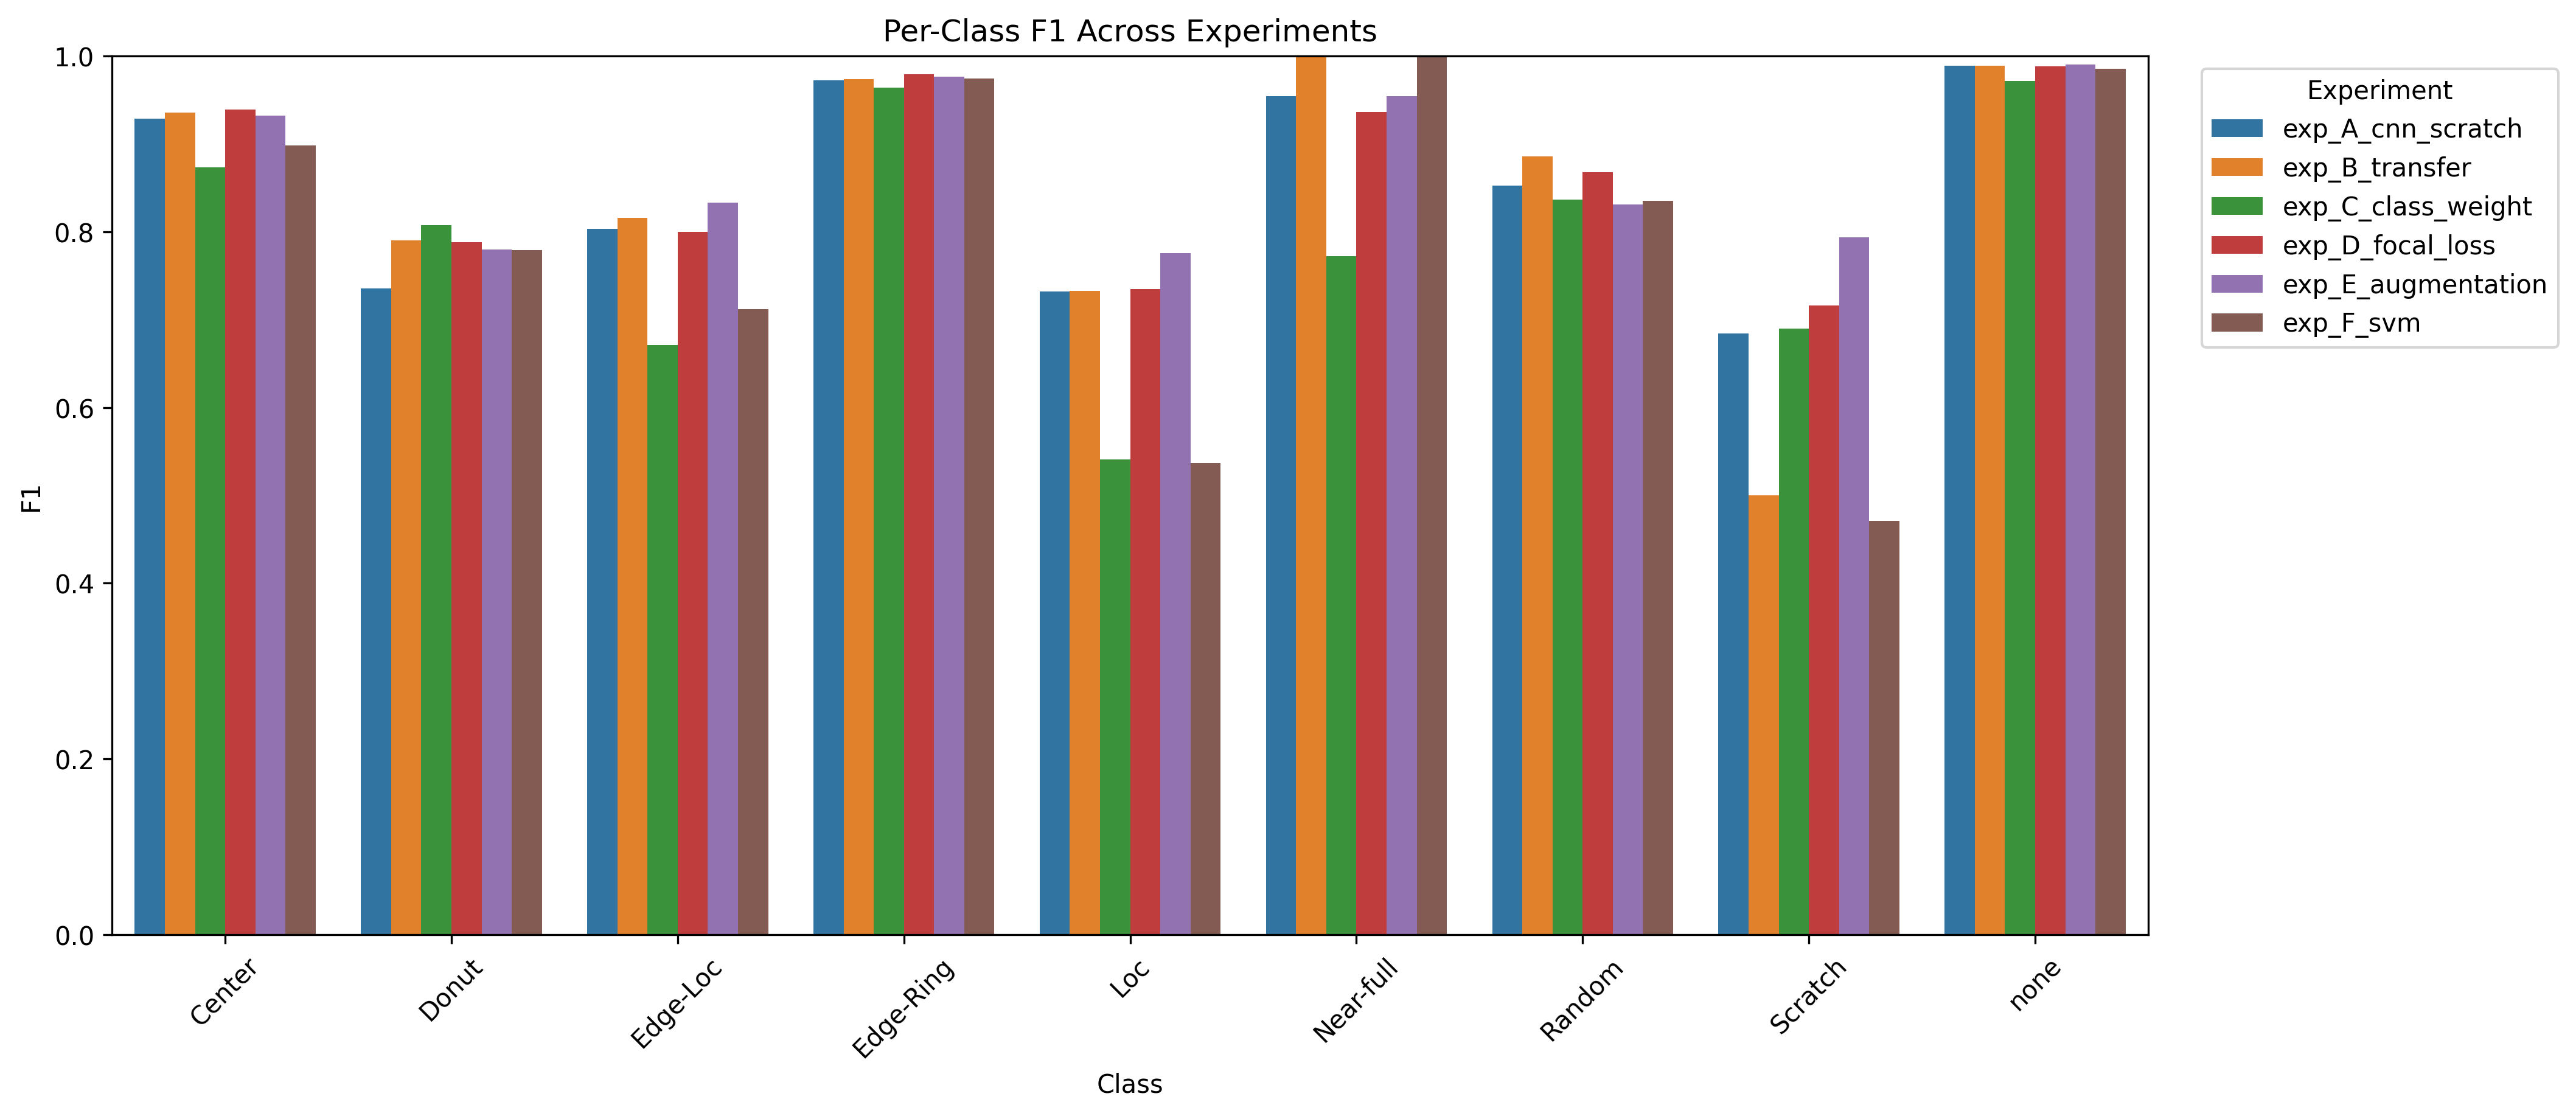

In [3]:
f1_columns = [f"f1_{class_name}" for class_name in LABELS]
long_df = comparison_df.melt(
    id_vars="experiment",
    value_vars=f1_columns,
    var_name="class_name",
    value_name="f1",
)
long_df["class_name"] = long_df["class_name"].str.replace("f1_", "", regex=False)

fig, ax = plt.subplots(figsize=(14, 6), constrained_layout=True)
sns.barplot(data=long_df, x="class_name", y="f1", hue="experiment", ax=ax)
ax.set_title("Per-Class F1 Across Experiments")
ax.set_xlabel("Class")
ax.set_ylabel("F1")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Experiment", bbox_to_anchor=(1.02, 1), loc="upper left")
money_chart = FIGURE_DIR / "per_class_f1_comparison.png"
fig.savefig(money_chart, dpi=300, bbox_inches="tight")
plt.close(fig)
display(Image(filename=money_chart))

## Intervention Highlights

In [4]:
baseline_name = "exp_A_cnn_scratch"
if baseline_name not in set(comparison_df["experiment"]):
    display(Markdown("Baseline experiment A is not available yet."))
else:
    baseline = comparison_df.set_index("experiment").loc[baseline_name]
    lines = []
    for _, row in comparison_df.iterrows():
        exp_name = row["experiment"]
        if exp_name == baseline_name:
            continue
        deltas = row[f1_columns] - baseline[f1_columns]
        best_class = deltas.idxmax().replace("f1_", "")
        worst_class = deltas.idxmin().replace("f1_", "")
        lines.append(
            f"- `{exp_name}`: largest gain `{best_class}` "
            f"({deltas.max():+.3f}); largest drop `{worst_class}` "
            f"({deltas.min():+.3f})."
        )
    if lines:
        display(Markdown("\n".join(lines)))
    else:
        display(Markdown("Only baseline A is available so far; rerun after experiments B-F complete."))

- `exp_B_transfer`: largest gain `Donut` (+0.054); largest drop `Scratch` (-0.184).
- `exp_C_class_weight`: largest gain `Donut` (+0.072); largest drop `Loc` (-0.191).
- `exp_D_focal_loss`: largest gain `Donut` (+0.052); largest drop `Near-full` (-0.018).
- `exp_E_augmentation`: largest gain `Scratch` (+0.109); largest drop `Random` (-0.022).
- `exp_F_svm`: largest gain `Near-full` (+0.045); largest drop `Scratch` (-0.213).